# 1 · Análisis exploratorio (EDA)
## WiDS Datathon 2026 — Data Wizards

Predecimos, a partir de las **primeras 5 h** de un incendio, la probabilidad de que
llegue a ≤ 5 km de una zona de evacuación a los horizontes 12 / 24 / 48 / 72 h. Es un
problema de **análisis de supervivencia con censura a derecha**:

- `time_to_hit_hours` — horas hasta llegar a la zona (o último tiempo observado si no llegó).
- `event` — `1` si llegó dentro de 72 h, `0` si está censurado.

Este notebook recorre los datos hasta el **hallazgo que condiciona todo el proyecto**:
existe una *separación casi perfecta por distancia* a los 5 km.

In [1]:
import sys
from pathlib import Path

_SRC = next((p for p in ["src", "../src"] if (Path(p) / "wids_common.py").exists()), None)
if _SRC and _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

from wids_common import find_data_dir, setup_style, FEATURE_GROUPS, HORIZONS

PALETTE, C0, C1, C2, C3 = setup_style()
DATA_DIR = find_data_dir()
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Aquí cargamos los datos crudos (sin feature engineering) porque el EDA describe
# las variables originales.
df_train = pd.read_csv(DATA_DIR / "train.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")
print(f"train: {df_train.shape}  |  test: {df_test.shape}")

train: (221, 37)  |  test: (95, 35)


## 1.1 Calidad de datos

Antes de modelar, confirmamos que no hay que imputar ni deduplicar.

In [2]:
print("Nulos en train:", int(df_train.isnull().sum().sum()))
print("Nulos en test :", int(df_test.isnull().sum().sum()))
print("Duplicados train:", int(df_train.duplicated().sum()))
print(f"\nObservaciones: {len(df_train)} train, {len(df_test)} test, {df_train.shape[1] - 3} features.")

Nulos en train: 0
Nulos en test : 0
Duplicados train: 0

Observaciones: 221 train, 95 test, 34 features.


Sin nulos ni duplicados: los datos vienen limpios. El reto no es la limpieza
sino el **tamaño pequeño** (221 incendios) y la **censura**.

## 1.2 La variable objetivo

Solo el **31 %** de los incendios llegó a la zona dentro de 72 h. El resto está
*censurado*: no sabemos si habría llegado más tarde, solo que no lo hizo en la ventana.

Eventos (llegaron ≤72h): 69  (31.2%)
Censurados             : 152  (68.8%)


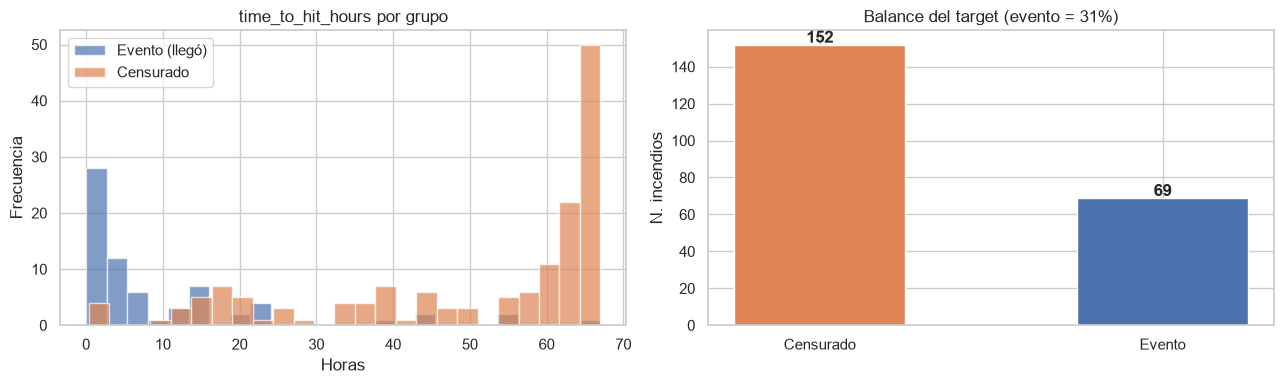

In [3]:
n_event = int(df_train["event"].sum())
n_cens = len(df_train) - n_event
event_rate = df_train["event"].mean()
print(f"Eventos (llegaron ≤72h): {n_event}  ({event_rate:.1%})")
print(f"Censurados             : {n_cens}  ({1 - event_rate:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ev, label, color in [(1, "Evento (llegó)", C0), (0, "Censurado", C1)]:
    sub = df_train[df_train["event"] == ev]["time_to_hit_hours"]
    axes[0].hist(sub, bins=25, alpha=0.7, label=label, color=color, edgecolor="white")
axes[0].set(title="time_to_hit_hours por grupo", xlabel="Horas", ylabel="Frecuencia")
axes[0].legend()

axes[1].bar(["Censurado", "Evento"], [n_cens, n_event], color=[C1, C0], edgecolor="white", width=0.5)
axes[1].set(title=f"Balance del target (evento = {event_rate:.0%})", ylabel="N. incendios")
for i, v in enumerate([n_cens, n_event]):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.3 Distribución de features por grupo

Las 34 features se agrupan en distancia, crecimiento, cinemática del centroide,
direccionalidad, cobertura temporal y metadata. Coloreamos por `event` para ver
cuáles separan visualmente a los dos grupos.

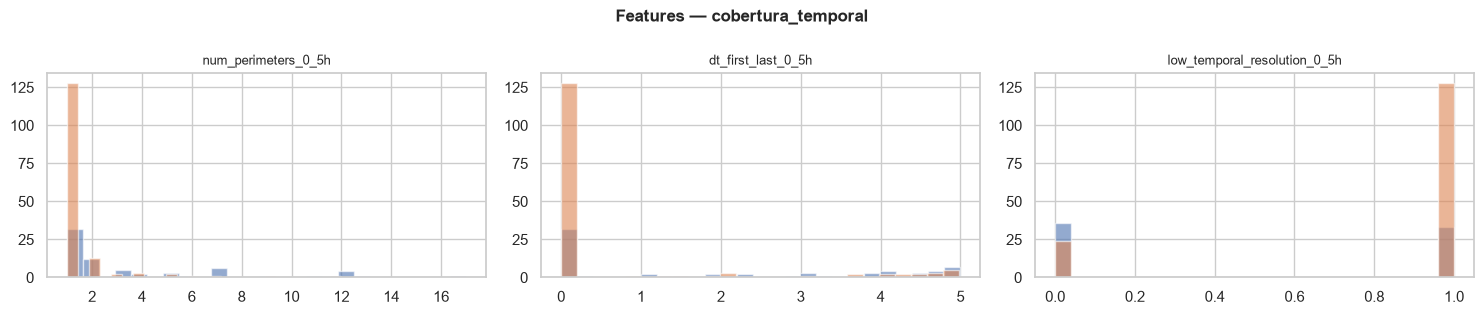

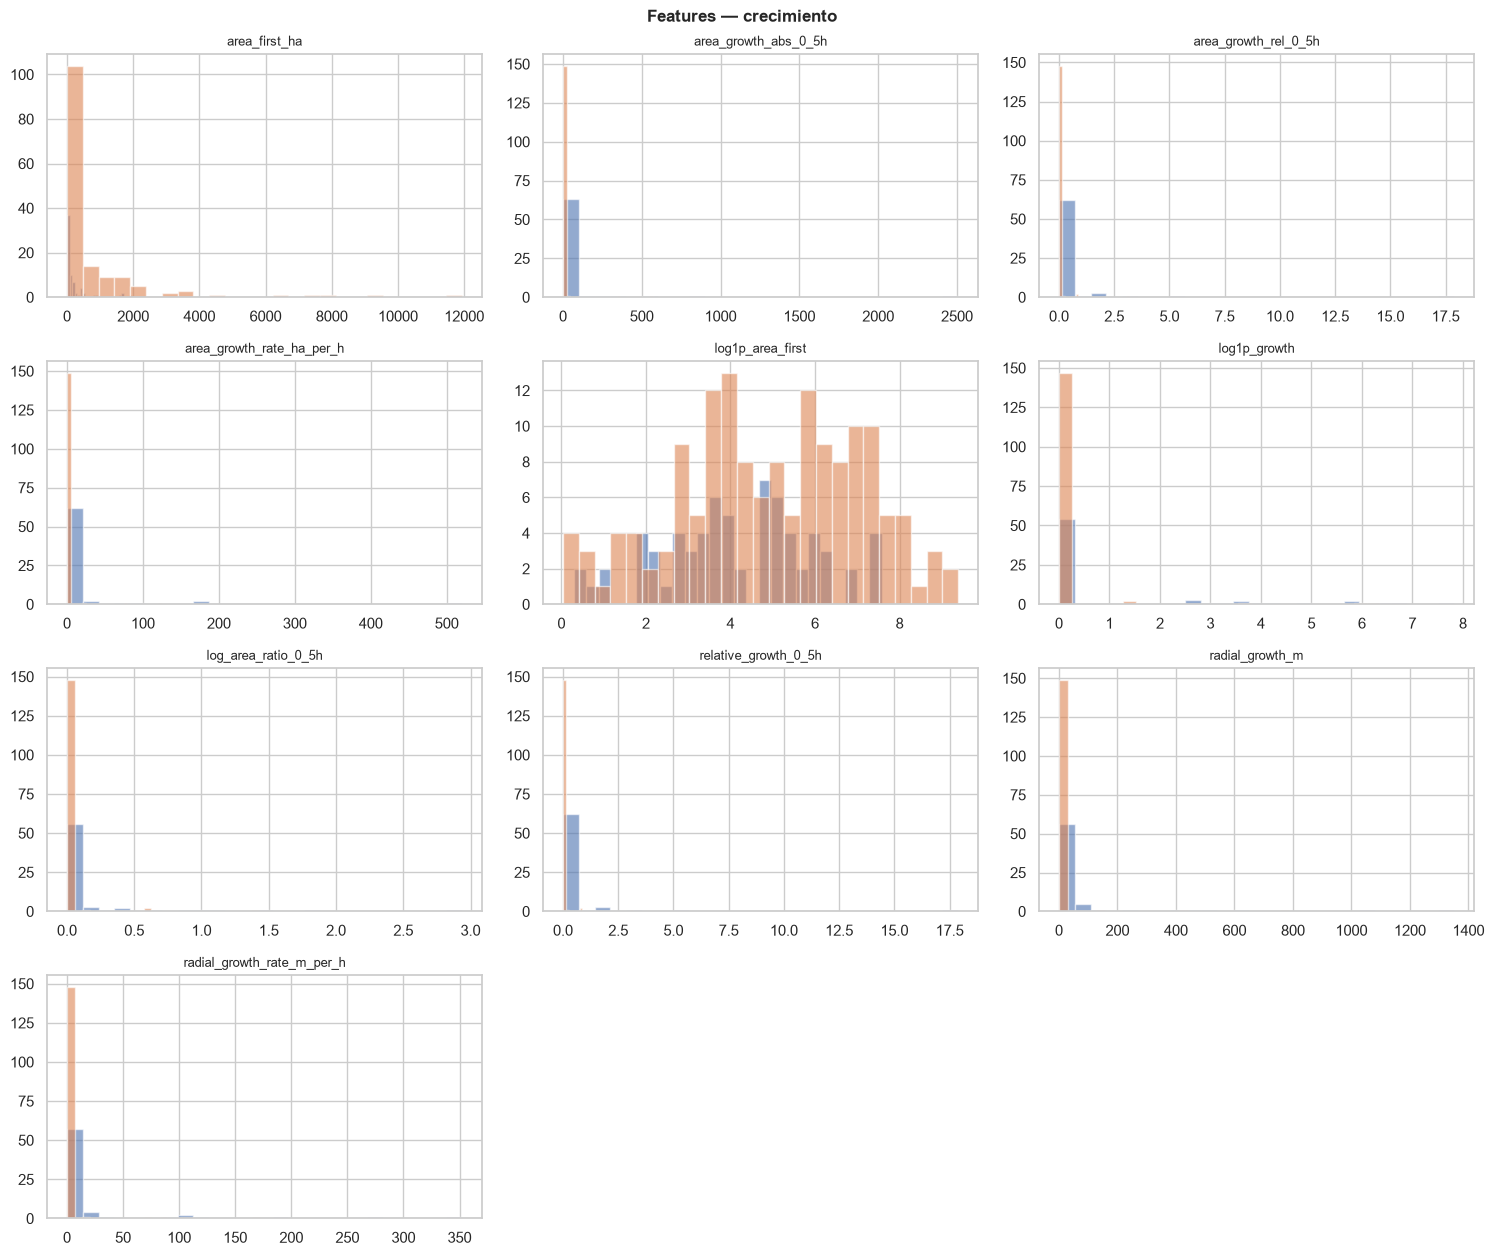

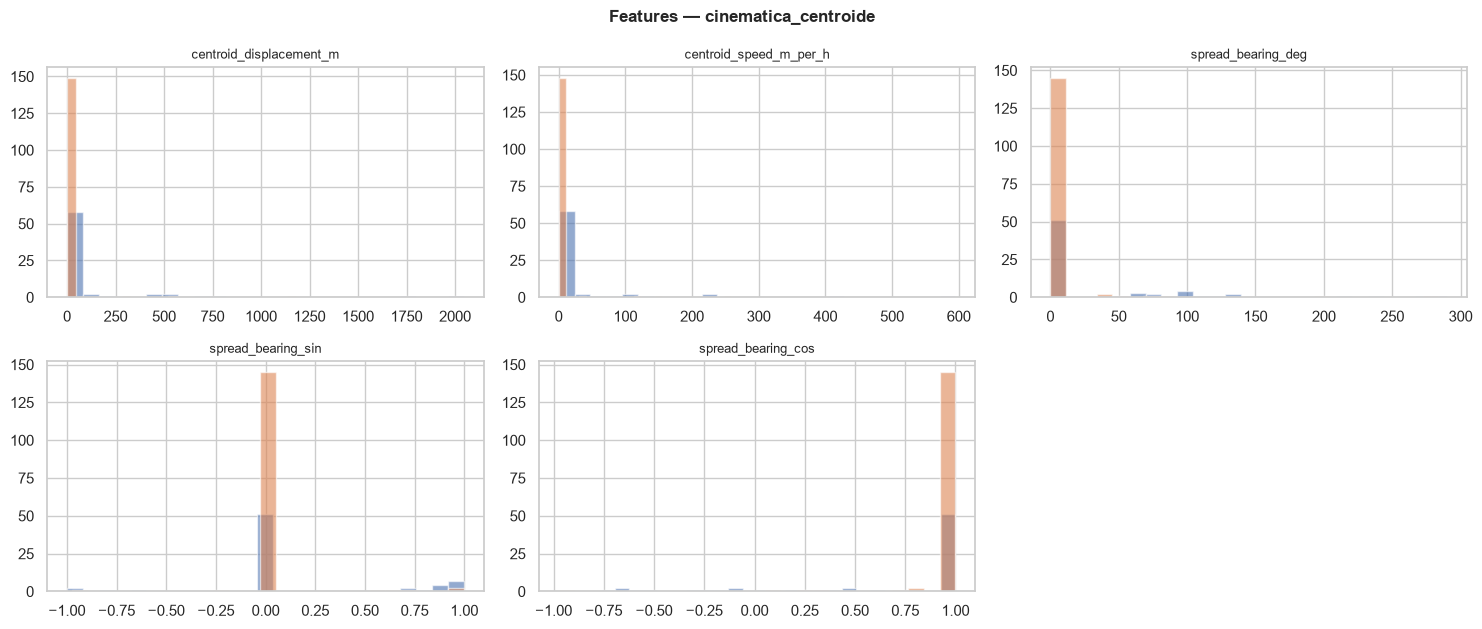

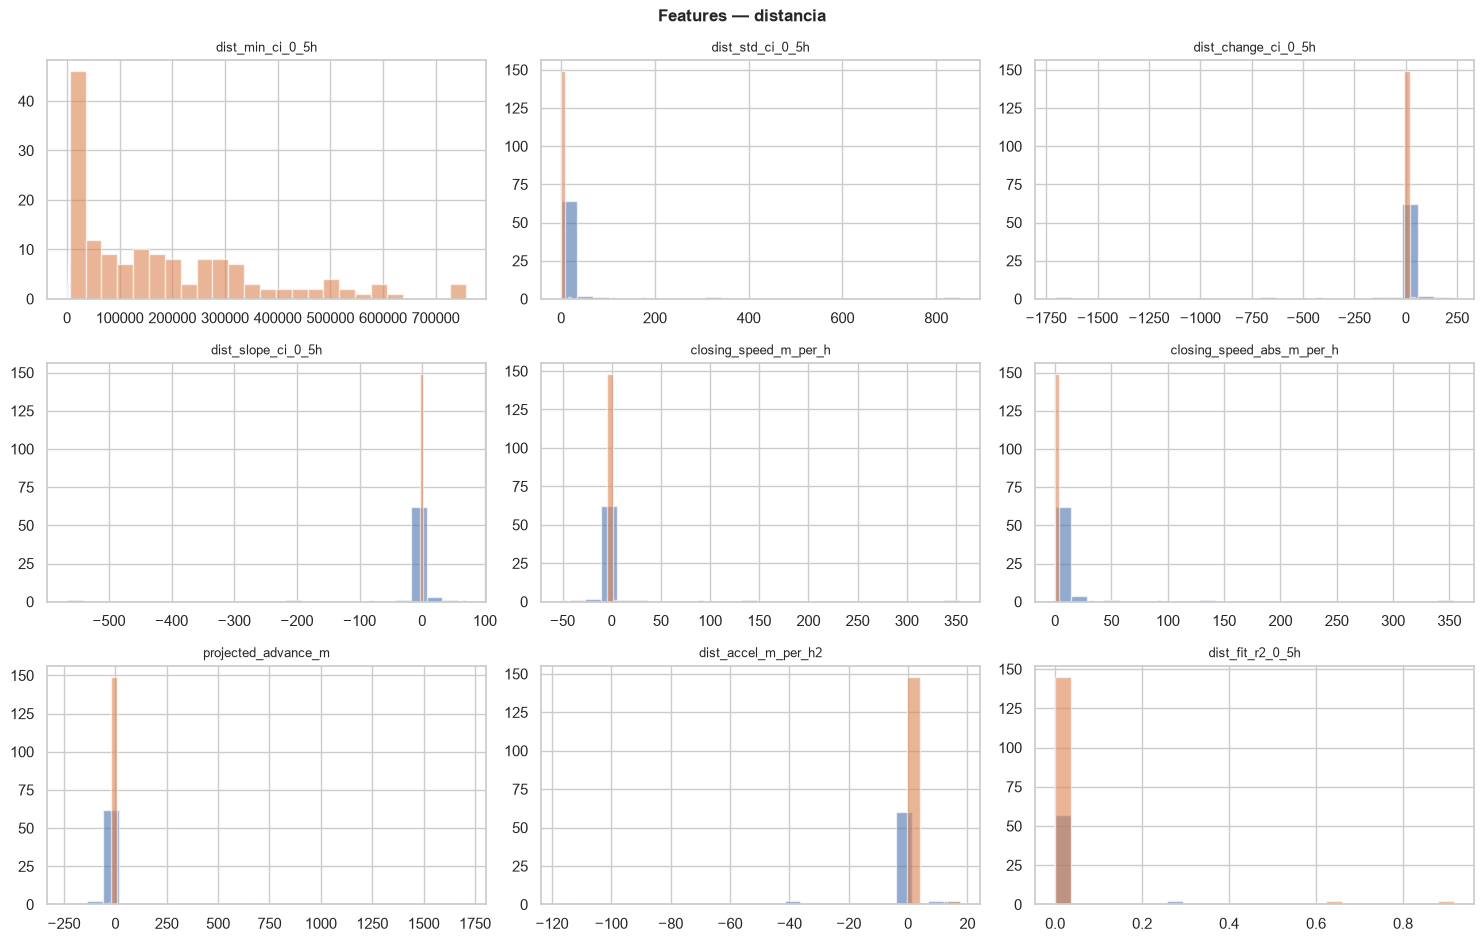

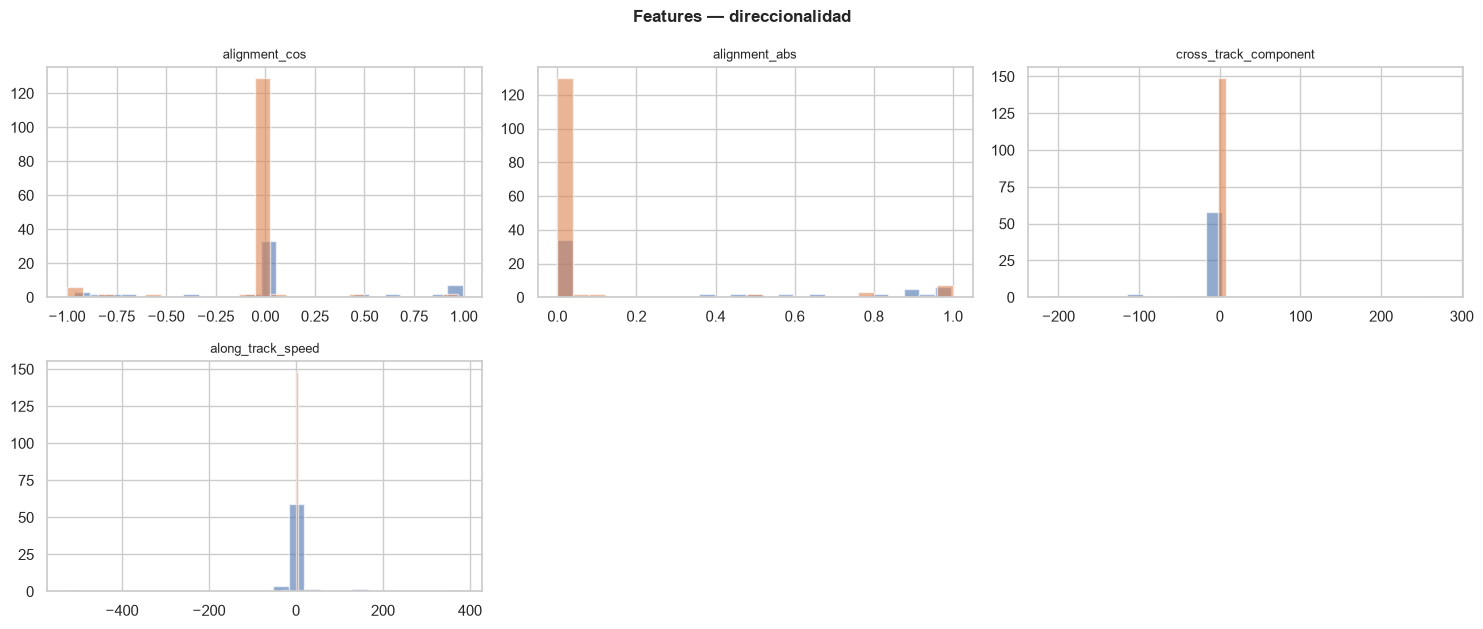

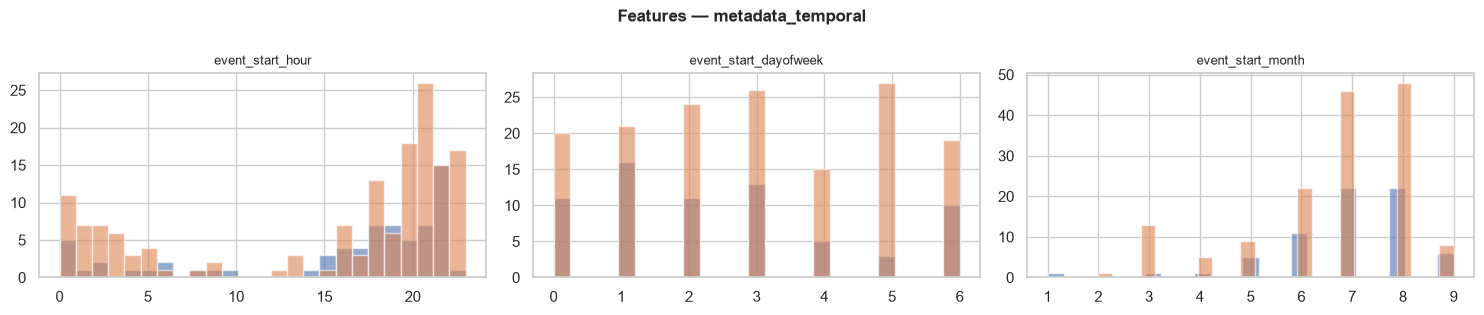

In [4]:
def plot_group(name, cols):
    cols = [c for c in cols if c in df_train.columns]
    ncols = 3
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cols):
        for ev, color in [(1, C0), (0, C1)]:
            axes[i].hist(df_train[df_train["event"] == ev][col].dropna(),
                         bins=25, alpha=0.6, color=color, edgecolor="white")
        axes[i].set_title(col, fontsize=9)
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"Features — {name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"02_features_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for name, cols in FEATURE_GROUPS.items():
    plot_group(name, cols)

`dist_min_ci_0_5h` (distancia mínima a la zona) separa los grupos de forma casi
binaria: los eventos se concentran en valores pequeños. Lo confirmamos abajo.

## 1.4 Correlaciones (Spearman)

Usamos **Spearman** (rangos) y no Pearson porque las relaciones son monótonas pero
no lineales (el riesgo cae logarítmicamente con la distancia), hay outliers y colas
largas. El heatmap revela bloques de features muy correlacionadas → multicolinealidad
a tratar en la selección de features.

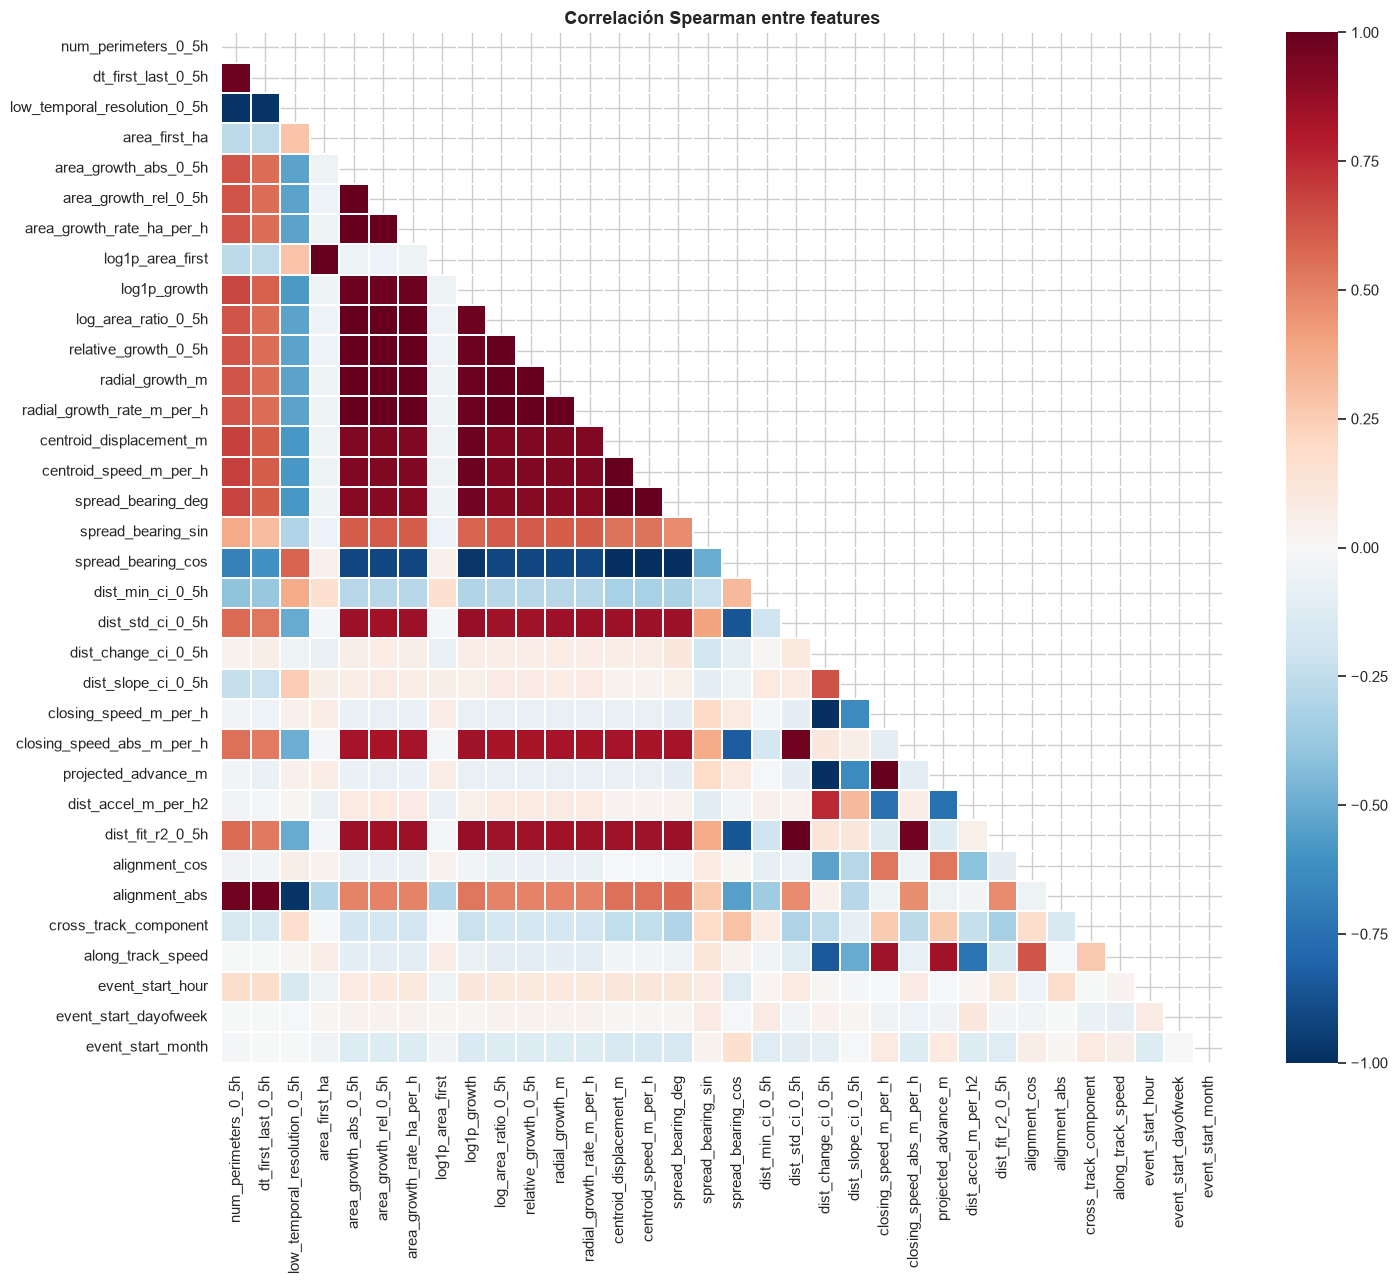

In [5]:
feat_cols = [c for g in FEATURE_GROUPS.values() for c in g if c in df_train.columns]
corr = df_train[feat_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax)
ax.set_title("Correlación Spearman entre features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

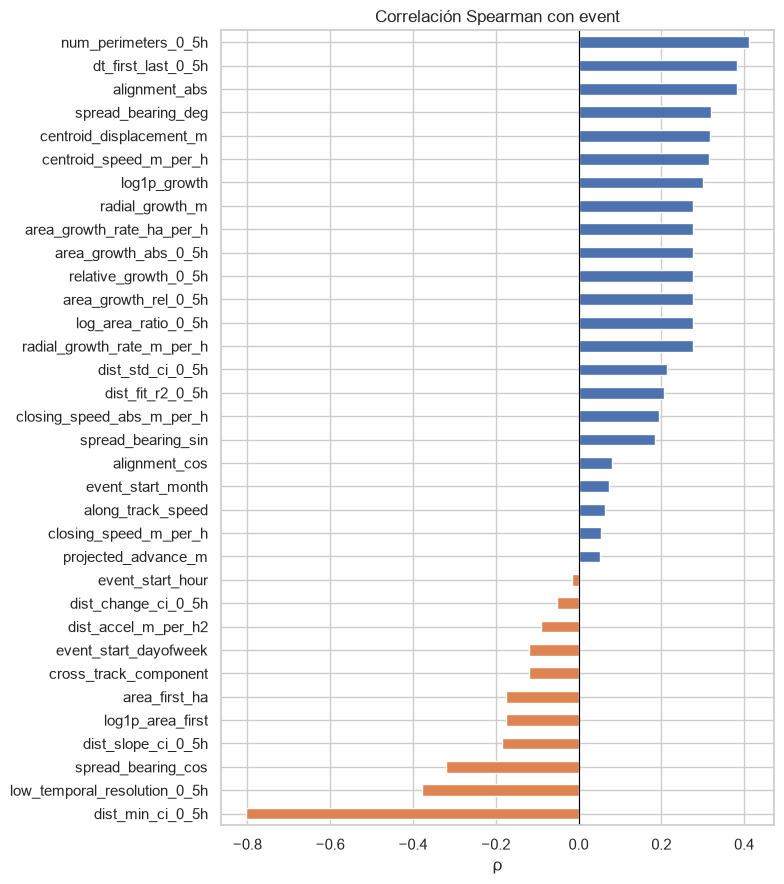

Top 5 |ρ| con event:
dist_min_ci_0_5h                0.802637
num_perimeters_0_5h             0.411458
dt_first_last_0_5h              0.383550
alignment_abs                   0.382967
low_temporal_resolution_0_5h    0.379117


In [6]:
corr_event = (df_train[feat_cols + ["event"]].corr(method="spearman")["event"]
              .drop("event").sort_values())
fig, ax = plt.subplots(figsize=(8, 9))
corr_event.plot(kind="barh", color=[C0 if v > 0 else C1 for v in corr_event], ax=ax, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Correlación Spearman con event", xlabel="ρ")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_feature_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 |ρ| con event:")
print(corr_event.abs().sort_values(ascending=False).head(5).to_string())

## 1.5 Curva de supervivencia global (Kaplan-Meier)

La KM estima S(t) = P(no haber llegado aún a la zona) sin asumir distribución y
manejando la censura. De aquí salen las probabilidades de un baseline ingenuo.

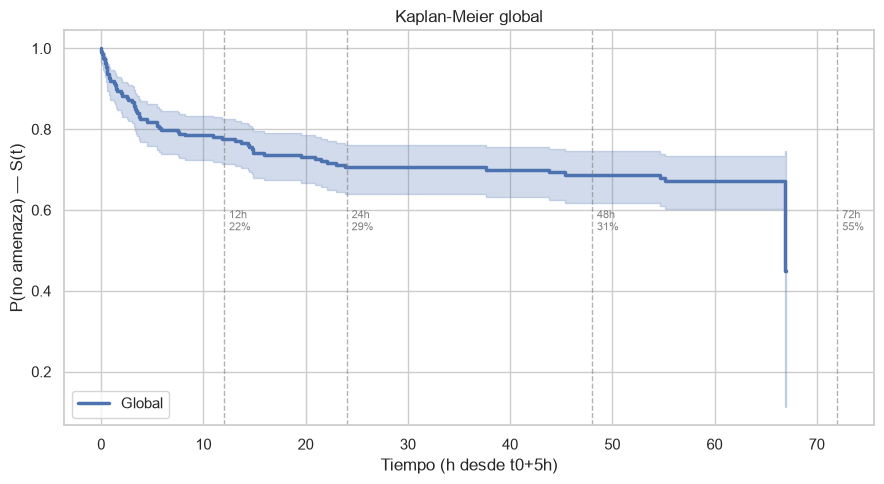

In [7]:
kmf = KaplanMeierFitter()
kmf.fit(df_train["time_to_hit_hours"], df_train["event"], label="Global")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax, lw=2.5, color=C0)
for h in HORIZONS:
    ax.axvline(h, color="gray", lw=1, ls="--", alpha=0.6)
    ax.text(h + 0.5, 0.55, f"{h}h\n{1 - float(kmf.predict(h)):.0%}", fontsize=8, color="gray")
ax.set(xlabel="Tiempo (h desde t0+5h)", ylabel="P(no amenaza) — S(t)",
       title="Kaplan-Meier global")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_km_global.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.6 El hallazgo clave: separación casi perfecta a 5 km

Si partimos los incendios en **cerca (< 5 km)** y **lejos (≥ 5 km)** al momento t0+5h,
las curvas de supervivencia se separan por completo. Este es el descubrimiento que
explica por qué `dist_min_ci_0_5h` domina cualquier modelo.

Cerca (<5 km) : n= 69  eventos=69 (100%)
Lejos (≥5 km) : n=152  eventos=0 (0%)
Log-rank p-value: 1.49e-70
Distancia máx. de un evento: 4.67 km


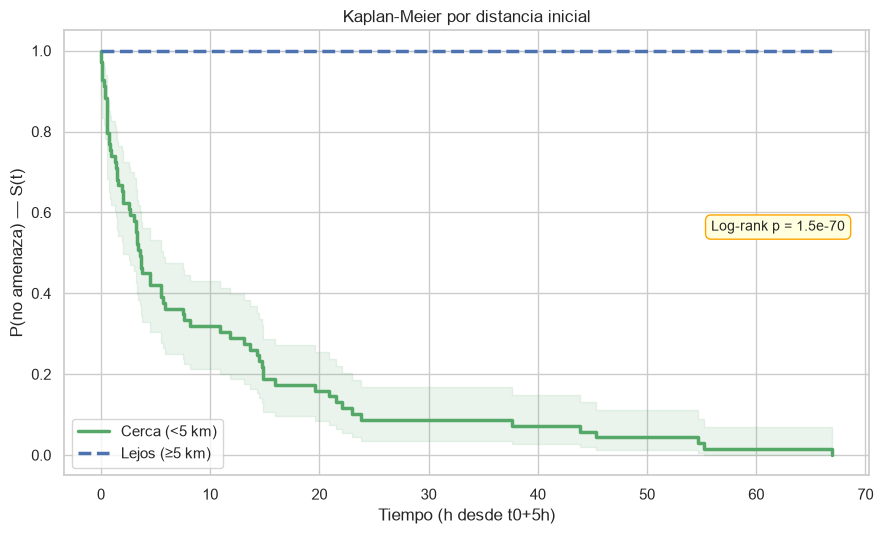

In [8]:
THRESHOLD = 5_000  # metros
cerca = df_train[df_train["dist_min_ci_0_5h"] < THRESHOLD]
lejos = df_train[df_train["dist_min_ci_0_5h"] >= THRESHOLD]
lr = logrank_test(cerca["time_to_hit_hours"], lejos["time_to_hit_hours"],
                  cerca["event"], lejos["event"])

print(f"Cerca (<5 km) : n={len(cerca):>3}  eventos={cerca['event'].sum()} ({cerca['event'].mean():.0%})")
print(f"Lejos (≥5 km) : n={len(lejos):>3}  eventos={lejos['event'].sum()} ({lejos['event'].mean():.0%})")
print(f"Log-rank p-value: {lr.p_value:.2e}")
print(f"Distancia máx. de un evento: {cerca['dist_min_ci_0_5h'].max() / 1000:.2f} km")

fig, ax = plt.subplots(figsize=(9, 5.5))
for grupo, sub, color, ls in [("Cerca (<5 km)", cerca, C2, "-"),
                              ("Lejos (≥5 km)", lejos, C0, "--")]:
    kmf.fit(sub["time_to_hit_hours"], sub["event"], label=grupo)
    kmf.plot_survival_function(ax=ax, lw=2.5, linestyle=ls, color=color, ci_alpha=0.12)
ax.set(xlabel="Tiempo (h desde t0+5h)", ylabel="P(no amenaza) — S(t)",
       title="Kaplan-Meier por distancia inicial")
ax.annotate(f"Log-rank p = {lr.p_value:.1e}", xy=(0.97, 0.55), xycoords="axes fraction",
            ha="right", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="orange"))
plt.tight_layout()
plt.savefig(FIG_DIR / "18_km_cerca_vs_lejos.png", dpi=150, bbox_inches="tight")
plt.show()

**Separación casi perfecta:** los 69 incendios que llegaron están **todos** a < 5 km;
los 152 censurados, **todos** a ≥ 5 km (log-rank p ≈ 1.5×10⁻⁷⁰). La distancia inicial
es prácticamente determinista en train. Esto tendrá dos consecuencias: (1) cualquier
modelo razonable alcanzará C-index ~0.95, y (2) habrá que vigilar la extrapolación.

## 1.7 Distancia: detalle por evento

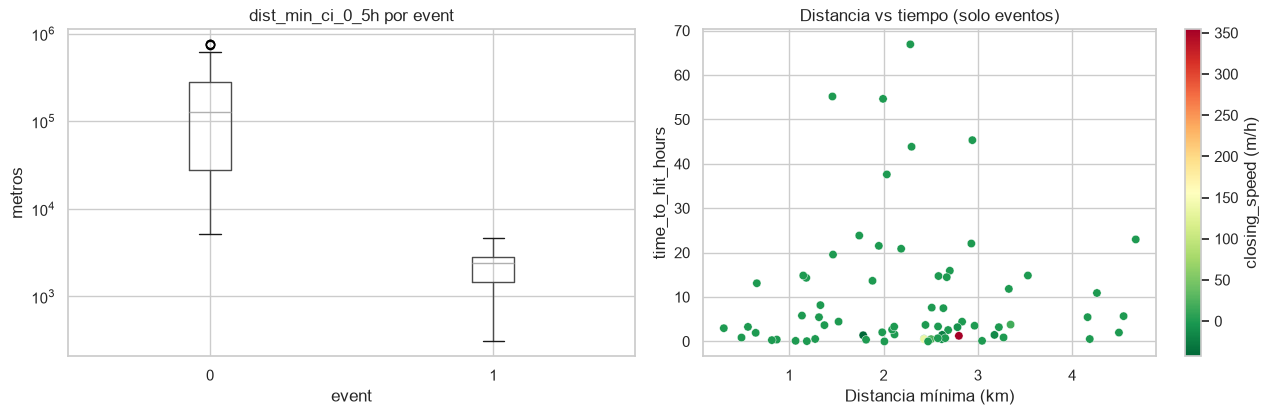

          min       50%       max
event                            
0      5216.0  128842.0  757700.0
1       307.0    2430.0    4674.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_train.boxplot(column="dist_min_ci_0_5h", by="event", ax=axes[0])
axes[0].set(title="dist_min_ci_0_5h por event", xlabel="event", ylabel="metros")
axes[0].set_yscale("log")
plt.sca(axes[0]); plt.title("dist_min_ci_0_5h por event")

ev = df_train[df_train["event"] == 1]
sc = axes[1].scatter(ev["dist_min_ci_0_5h"] / 1000, ev["time_to_hit_hours"],
                     c=ev["closing_speed_m_per_h"], cmap="RdYlGn_r", edgecolors="white", lw=0.3)
plt.colorbar(sc, ax=axes[1], label="closing_speed (m/h)")
axes[1].set(xlabel="Distancia mínima (km)", ylabel="time_to_hit_hours",
            title="Distancia vs tiempo (solo eventos)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_distance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_train.groupby("event")["dist_min_ci_0_5h"].describe()[["min", "50%", "max"]].round(0).to_string())

## 1.8 Zona gris en el test (5–15 km)

La separación perfecta tiene un costo: el train **nunca** observó incendios entre 5 y
15 km. Pero el test sí. Esos casos caen en una franja sin datos de entrenamiento, donde
el modelo tendrá que **extrapolar**. Lo cuantificamos.

Incendios en zona gris (5–15 km) en test: 7 (7.4%)


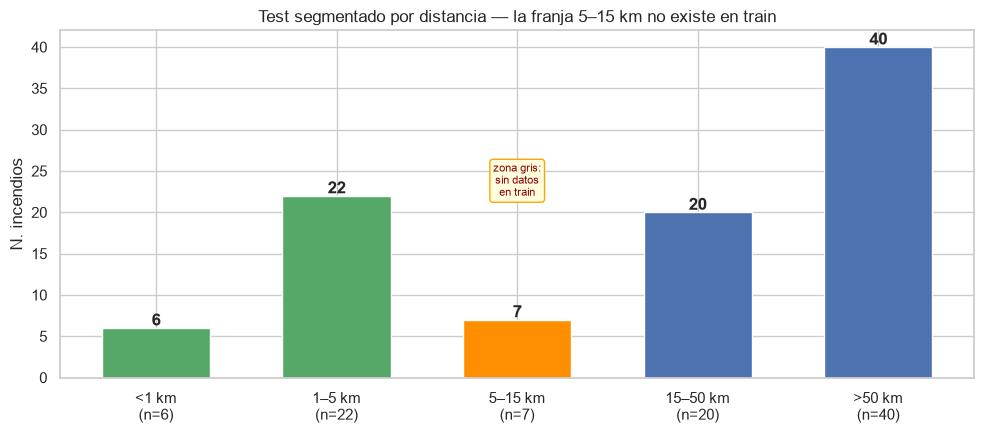

In [10]:
def franja(df, lo, hi):
    return int(((df["dist_min_ci_0_5h"] >= lo) & (df["dist_min_ci_0_5h"] < hi)).sum())

gris = df_test[(df_test["dist_min_ci_0_5h"] >= 5_000) & (df_test["dist_min_ci_0_5h"] < 15_000)]
print(f"Incendios en zona gris (5–15 km) en test: {len(gris)} ({len(gris) / len(df_test):.1%})")

franjas = [("<1 km", 0, 1e3), ("1–5 km", 1e3, 5e3), ("5–15 km", 5e3, 15e3),
           ("15–50 km", 15e3, 50e3), (">50 km", 50e3, np.inf)]
labels = [f"{n}\n(n={franja(df_test, lo, hi)})" for n, lo, hi in franjas]
counts = [franja(df_test, lo, hi) for _, lo, hi in franjas]

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [C2, C2, "#FF8F00", C0, C0]
bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.6)
for b, n in zip(bars, counts):
    if n:
        ax.text(b.get_x() + b.get_width() / 2, n + 0.3, str(n), ha="center", fontweight="bold")
ax.set(title="Test segmentado por distancia — la franja 5–15 km no existe en train", ylabel="N. incendios")
ax.annotate("zona gris:\nsin datos\nen train", xy=(2, max(counts) * 0.55), ha="center",
            fontsize=8, color="darkred",
            bbox=dict(boxstyle="round", fc="lightyellow", ec="orange"))
plt.tight_layout()
plt.savefig(FIG_DIR / "19_test_distance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.9 ¿Train y test se parecen? (data drift)

Comparamos cada feature entre train y test con el test de Kolmogórov-Smirnov. Un KS
bajo en casi todas indica que el CV en train será un buen proxy del test (lo
confirmamos formalmente en `validation.ipynb` con adversarial validation).

In [11]:
from scipy.stats import ks_2samp

common = [c for c in feat_cols if c in df_test.columns]
ks = pd.Series({c: ks_2samp(df_train[c].dropna(), df_test[c].dropna())[0] for c in common})
ks = ks.sort_values(ascending=False)
print("KS máximo:", round(ks.max(), 3), "→", ks.idxmax())
print("\nTop 5 features con mayor drift:")
print(ks.head(5).round(3).to_string())

KS máximo: 0.109 → event_start_dayofweek

Top 5 features con mayor drift:
event_start_dayofweek    0.109
dist_min_ci_0_5h         0.085
alignment_abs            0.073
dist_accel_m_per_h2      0.066
event_start_hour         0.062


## Resumen del EDA

- Datos limpios; el reto es el tamaño (n=221) y la censura (69 % censurados).
- **Separación casi perfecta a 5 km**: la distancia inicial casi determina el evento
  en train (log-rank p ≈ 1.5×10⁻⁷⁰) → justifica supervivencia y anticipa C-index ~0.95.
- **Zona gris (5–15 km)**: 7 incendios de test caen fuera del rango de train → riesgo
  de extrapolación, documentado.
- Drift train/test bajo (KS máx ≈ 0.11) → la validación en train debería transferir.

Siguiente paso: **selección de features por modelo** (`feature_selection.ipynb`).